In [19]:
import sys

sys.path.insert(1,"../src/")

from utilities import find_peaks, wideband_pulse
import warping

In [235]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp
from scipy.ndimage import label

from scipy.special import softmax

In [21]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [22]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

NPERSEG = 80

NPEAKS = 20

In [118]:
wb_pulse_params = dict(pulse_duration=0.2, fs=SAMPLING_FREQ, bw=200, fc=350, window=sp.windows.tukey)

In [119]:
data1 = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")

f = data1['f'].squeeze()
c = data1['soundspeed'].squeeze()
Vg = data1['Vg'][:,:,c == TRUE_SOUNDSPEED,...].squeeze()
source_range = data1['range'][0,0]

In [120]:
df = f[1] - f[0]

#t0 = 0
t0 = source_range*1e3/1500
N = SAMPLING_FREQ/df

In [121]:
X = data1["g"][1, data1["soundspeed"]==TRUE_SOUNDSPEED].squeeze()

In [122]:
X = X  * np.exp(1j*2*np.pi*f*t0);
# x = np.real(np.ifft(X,N) * exp(1i*2*pi*(0:N-1)'*f(1)/SAMPLING_FREQ);

x = np.real(np.fft.ifft(X,int(N)) * np.exp(1j*2*np.pi*np.arange(N)*f[0]/SAMPLING_FREQ))
tx = np.arange(N)/SAMPLING_FREQ + t0

In [123]:
h = wideband_pulse(**wb_pulse_params)

x = sp.filtfilt(h, 1, x)

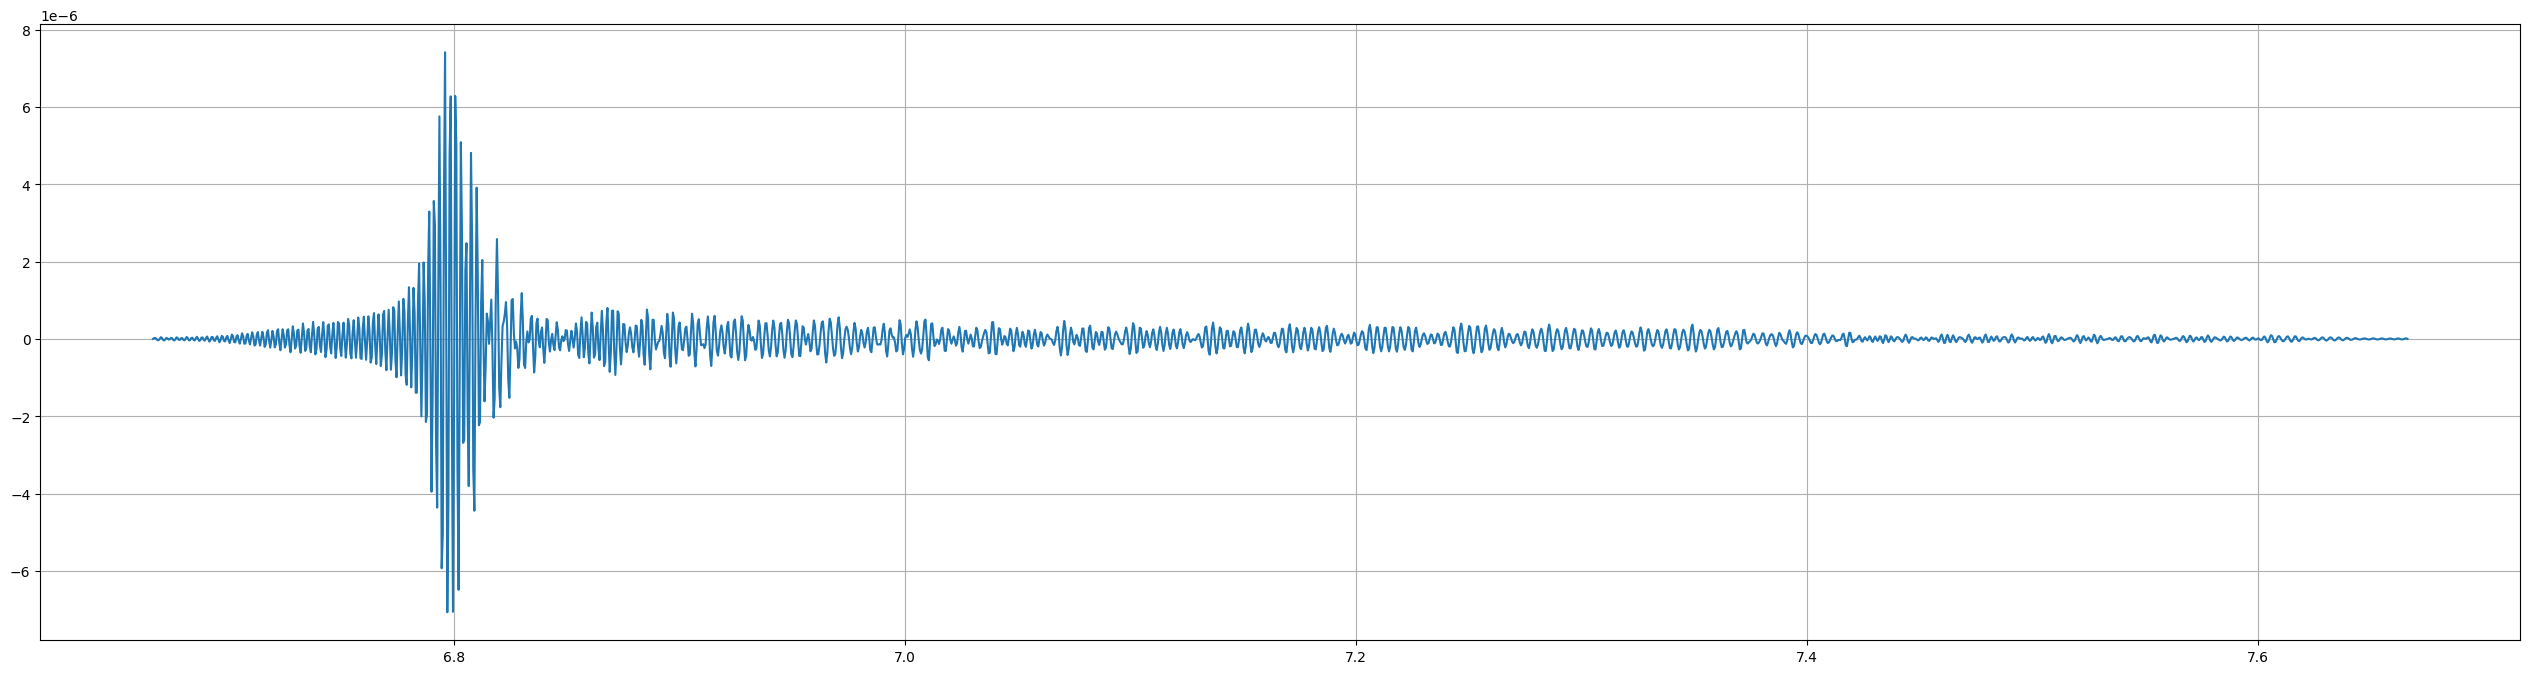

In [492]:
fig, ax = plt.subplots()
ax.plot(tx, x)

ax.grid()

fig.set_size_inches([32, 8])

## Spectrogram Compared to Mode Curves

In [125]:
[w, t, X] = sp.spectrogram(x, SAMPLING_FREQ, 'hamm', NPERSEG, NPERSEG-1, 2000)
t = t + t0

w = w[201:502]
X = X[201:502, :]

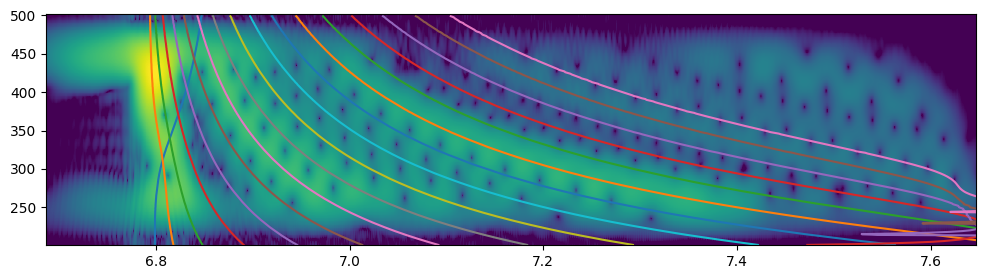

In [126]:
fig, ax = plt.subplots()
[low, high] = np.quantile(10*np.log10(X), [1e-1, 1])

ax.pcolormesh(t, w, 10*np.log10(X), vmin=low, vmax=high)

ax.plot(source_range*1e3/Vg.T, f[1:-1])
ax.set_xlim(t[[0, -1]])

fig.set_size_inches([12,3])


## Warping

In [514]:
origin_time = 6.8

x_warped, tw, fsw = warping.nonlinear_warping(x[tx>=origin_time], SAMPLING_FREQ, t0)

In [515]:
nperseg = 1500
nfft = 2000
[ww, txw, Xw] = sp.stft(x_warped, fsw, 'hamm', nperseg, nperseg-1, nfft)

logistic = lambda x,c,sigma: 1/(1+np.exp(-(x-c)/sigma))

#XF = softmax(np.abs(Xw)**2/2/np.var(np.abs(Xw), axis=1)[:,np.newaxis], axis=1)

XF = logistic(np.abs(Xw), np.median(np.abs(Xw)), np.std(np.abs(Xw)))

# peaksw = find_peaks(np.abs(Xw.mT)**2, txw, ww,10, np.quantile(np.abs(Xw)**2, .95))

In [516]:
np.quantile(XF, [0,1], axis=1)

array([[0.49946791, 0.49948282, 0.49947334, ..., 0.49946708, 0.49946707,
        0.49946707],
       [0.9854407 , 0.98754059, 0.99314593, ..., 0.50192211, 0.50142936,
        0.50184505]])

In [517]:
#Xw_bool = np.abs(Xw)**2 > np.quantile(np.abs(Xw)**2, 0.99)
Xw_bool = XF >.9

In [518]:
labeled_data, nlabels = label(Xw_bool)

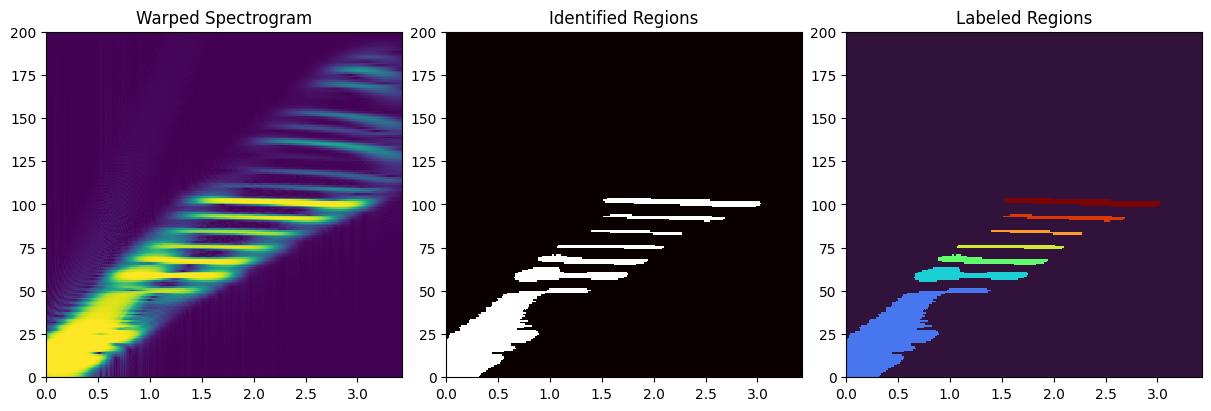

In [519]:
fig, (ax, axbool, axl) = plt.subplots(1,3, layout='constrained')

#[vmin, vmax] = np.quantile(XF, [0, .99])

ax.pcolormesh(txw, ww, XF)

#ax.scatter(peaksw[:,1], peaksw[:,0], c='orange', marker='x')

ax.set_ylim([0, 200])

ax.set_title("Warped Spectrogram")

axbool.pcolormesh(txw, ww, Xw_bool, cmap="hot")
axbool.set_ylim([0, 200])
axbool.set_title("Identified Regions")


axl.pcolormesh(txw, ww, labeled_data, cmap='turbo')
axl.set_ylim([0, 200])
axl.set_title("Labeled Regions")

fig.set_size_inches([12,4])

#fig.savefig('../data/output/figures/timewarping_labeled.png', dpi=600)

In [520]:
[U, V] = np.gradient(np.abs(Xw)**2)

AA = np.linalg.norm(np.array([U,V]), axis=0)**2

In [521]:
x_components = np.empty((nlabels, np.int64(N)))

for i_label in range(nlabels):
    mask_now = labeled_data == i_label
    X_comp_now = Xw * mask_now

    xnow = sp.istft(X_comp_now, fsw, 'hamm', nperseg, nperseg-1, nfft)[1]

    x_components[i_label] = warping.inv_nonlinear_warping(xnow, fsw, origin_time, SAMPLING_FREQ, N)[0]

[wc, tc, X_components] = sp.stft(x_components, SAMPLING_FREQ, 'hamm', NPERSEG, NPERSEG - 1, 2000)

fmask = np.all([wc>=200, wc<=500], 0) 
wc = wc[fmask]    
X_components = X_components[:, fmask, :]


In [522]:
nr

6

Text(0.02, 0.5, 'Frequency (Hz)')

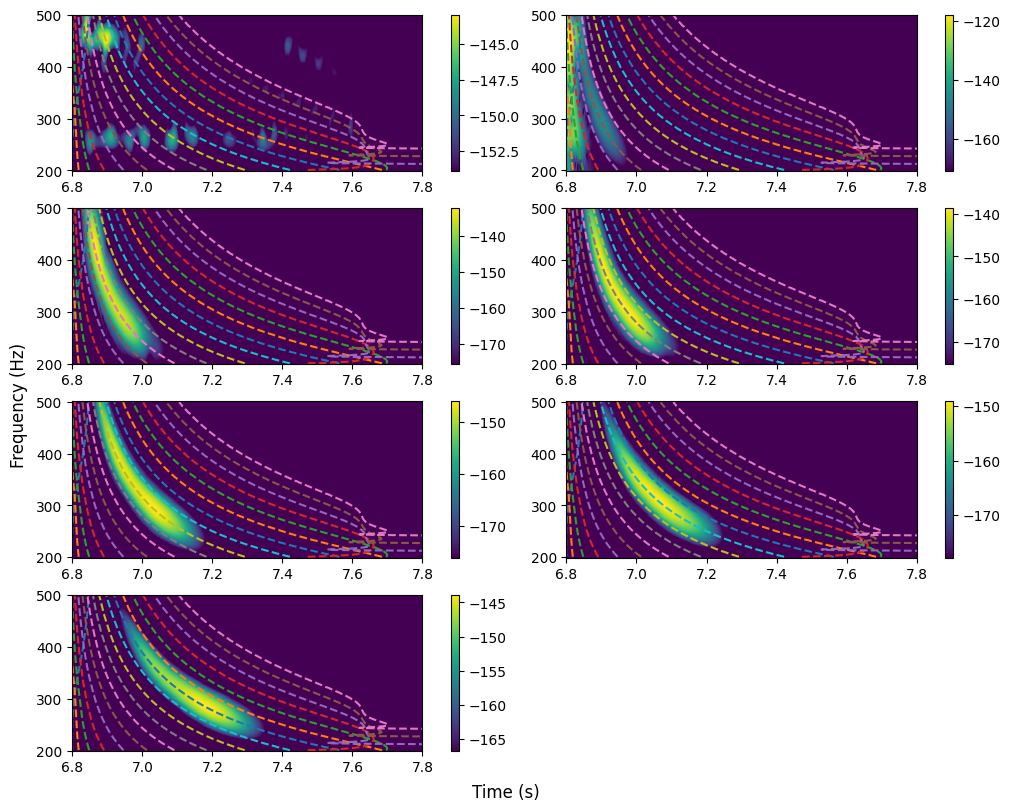

In [528]:
fig = plt.figure(layout='constrained')

vmin, vmax = np.quantile(20*np.log10(np.abs(X_components)), [.9, 1], [1,2])


nc = 2
nr = int(np.ceil(nlabels/2))

for ind in range(nlabels):
    ax = fig.add_subplot(nr, 2, ind + 1)
    m = ax.pcolormesh(tc + 6.8, wc, 20*np.log10(np.abs(X_components[ind])), vmin=vmin[ind], vmax=vmax[ind])
    ax.plot(source_range*1e3/Vg.T, f[1:-1], '--')
    ax.set_xlim(tc[[0,-1]] + 6.8)

    plt.colorbar(m, ax=ax)
fig.set_size_inches([10,8])    
fig.supxlabel('Time (s)')
fig.supylabel('Frequency (Hz)')
#fig.savefig('../data/output/figures/timewarping_extracted_components.png', dpi=600)


In [524]:
peaks_components = list()

min_height = np.quantile(np.abs(X_components)**2, .9, [1,2])

for ind, Xc in enumerate(np.abs(X_components)**2):
    peaks_components.append(find_peaks(Xc.mT, tc + 6.8, wc, npeaks=, min_height = min_height[ind]))


Text(0.5, 0.98, 'Arrival times from unwarped data')

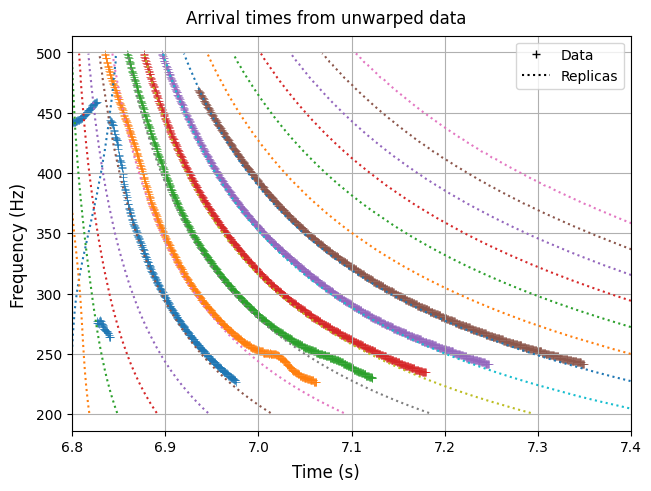

In [527]:
fig, ax = plt.subplots(layout='constrained')

ax.grid()
for p in peaks_components[1:11]:
    ax.scatter(p[:,1], p[:,0], marker = '+', linewidths=.5)
ax.plot(source_range*1e3/Vg.T, f[1:-1], ':')
ax.set_xlim([6.8, 7.4])

ax.plot(0, 350, 'k+', label="Data")
ax.plot(0, 350, 'k:', label="Replicas")

ax.legend()


fig.supxlabel('Time (s)')
fig.supylabel('Frequency (Hz)')

fig.suptitle("Arrival times from unwarped data")
#fig.set_size_inches([30,12])    

#fig.savefig('../data/output/figures/timewarping_arrival_times.png', dpi=600)

In [ ]:
export = {'peaks_coordinates':np.array(peaks_components[5:], dtype=object), 'mode_nos':np.array([9,10,11,12])}

np.savez('../data/output/warping_arrival_times.npz', **export)

In [ ]:
t = np.arange(201)/100

yy = np.sin(2*np.pi*5*t)

yyw, tyw, fsyw = warping.nonlinear_warping(yy, 100, 1e4/1500)
yuw, tyuw = warping.inv_nonlinear_warping(yyw, fsyw, 1e4/1500, 100, 201)

In [ ]:
fig, ax = plt.subplots(2,1)

ax[0].plot(t,yy)
ax[1].plot(tyw, yyw)
ax[1].set_xlim([0,6])

ax[0].plot(t, yuw, 'r--')